In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv('cleaned_SMSSpamCollection.csv')

In [3]:
df_copy = df.copy()

In [4]:
df_copy.head()

,label,message,label_num,message_length
0,ham,go jurong point crazi avail bugi n great world...,0,111
1,ham,ok lar joke wif u oni,0,29
2,spam,free entri 2 wkli comp win fa cup final tkt 21...,1,155
3,ham,u dun say earli hor u c alreadi say,0,49
4,ham,nah dont think goe usf live around though,0,61


In [27]:
df_copy[df_copy['message'].isnull()]

,label,message,label_num,message_length
940,ham,NaN,0,7
2677,ham,NaN,0,10
3193,ham,NaN,0,3
4278,ham,NaN,0,24
4502,ham,NaN,0,7


In [28]:
df_copy = df_copy.dropna(subset=['message'])


In [29]:
df_copy['message'].isnull().sum()

np.int64(0)

In [42]:
X = df_copy['message']
y = df_copy['label_num']

In [43]:
print(X.isnull().sum())
print(X.shape)

0
(5164,)


In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

0
0


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [47]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [48]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4131, 7093)
(1033, 7093)


# Train logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [50]:
model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [51]:
y_pred = model.predict(X_test_tfidf)

In [52]:
y_pred[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Performance metrics


In [53]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

# accuracy

In [54]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy score  : ",accuracy)

Accuracy score  :  0.9564375605033882


# Precision

In [56]:
precision = precision_score(y_test,y_pred)
print("Precision score  : ",precision)

Precision score  :  0.967391304347826


# Recall

In [57]:
recall = recall_score(y_test,y_pred)
print("Recall score : ",recall)

Recall score :  0.6793893129770993


# F1 score 

In [58]:
f1 = f1_score(y_test,y_pred)
print("F1 score : ",f1)

F1 score :  0.7982062780269058


# Classification Report

In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       902
           1       0.97      0.68      0.80       131

    accuracy                           0.96      1033
   macro avg       0.96      0.84      0.89      1033
weighted avg       0.96      0.96      0.95      1033



# confustion matrix

In [60]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[899   3]
 [ 42  89]]


# Heatmap

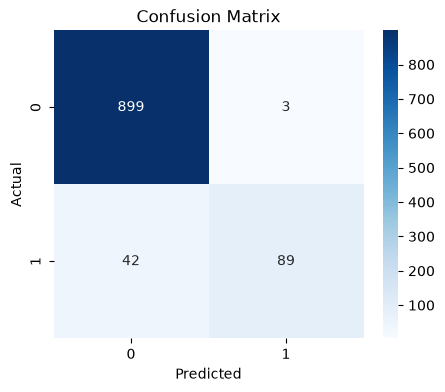

In [61]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Hyperparameter tuning to improve recall

In [62]:
from sklearn.linear_model import LogisticRegression
balanced_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

In [63]:
balanced_model.fit(X_train_tfidf,y_train)
y_pred_balanced = balanced_model.predict(X_test_tfidf)

In [64]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_balanced))

print(confusion_matrix(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       902
           1       0.90      0.94      0.92       131

    accuracy                           0.98      1033
   macro avg       0.94      0.96      0.95      1033
weighted avg       0.98      0.98      0.98      1033

[[888  14]
 [  8 123]]


# actual Hyperparameter tuning

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix

In [66]:
c_values = [0.01,0.1,1,10,100]

for c in c_values:
    tuning_model = LogisticRegression(
        C = c,
        class_weight='balanced',
        random_state=42
    )
    tuning_model.fit(X_train_tfidf,y_train)
    y_tuned_pred =tuning_model.predict(X_test_tfidf)
    
    print(" = " * 50)
    print(f" C = {c}")
    print(classification_report(y_test,y_tuned_pred))
    cm = confusion_matrix(y_test,y_tuned_pred)
    print(cm)

 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
 C = 0.01
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       902
           1       0.84      0.92      0.88       131

    accuracy                           0.97      1033
   macro avg       0.91      0.95      0.93      1033
weighted avg       0.97      0.97      0.97      1033

[[879  23]
 [ 11 120]]
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
 C = 0.1
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       902
           1       0.87      0.92      0.90       131

    accuracy                           0.97      1033
   macro avg       0.93      0.95      0.94      1033
weighted avg       0.97      0.97      0.97      1033

[[

# GridgeSearch CV

In [67]:
from sklearn.model_selection import GridSearchCV


In [68]:
log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

In [69]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

In [70]:
grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [71]:
grid.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with higherva

In [72]:
grid.best_params_

{'C': 100}

In [73]:
grid.best_score_

np.float64(0.8859127419993262)

In [74]:
best_model = grid.best_estimator_

In [75]:
y_grid_pred = best_model.predict(X_test_tfidf)

In [76]:
print(classification_report(y_test, y_grid_pred))

print(confusion_matrix(y_test, y_grid_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       902
           1       0.95      0.93      0.94       131

    accuracy                           0.99      1033
   macro avg       0.97      0.96      0.97      1033
weighted avg       0.99      0.99      0.99      1033

[[896   6]
 [  9 122]]


In [78]:
sms = "Congratulations! You have won a free iPhone. Click the link to claim your prize now"

In [79]:
sms_tfidf = tfidf.transform([sms])

In [87]:
prediction = best_model.predict(sms_tfidf)[0]

In [88]:
prediction

np.int64(1)

In [81]:
if prediction == 1:
    print("spam")
else:
    print("Ham")

spam


In [94]:
def predict_sms(message):
    
    # Convert message to TF-IDF
    message_tfidf = tfidf.transform([message])
    
    # Prediction
    prediction = best_model.predict(message_tfidf)[0]
    
    # Probability
    probability = best_model.predict_proba(message_tfidf)[0]
    
    ham_probability = probability[0] * 100
    spam_probability = probability[1] * 100
    
    result = "Spam" if prediction == 1 else "Ham"
    
    return {
        "Prediction": result,
        "Ham Probability": f"{ham_probability:.2f}%",
        "Spam Probability": f"{spam_probability:.2f}%"
    }

In [ ]:
predict_sms(
    "Congratulations! You won a free iPhone. Click this link to claim your prize"
)

{'Prediction': 'Spam',
 'Ham Probability': '0.04%',
 'Spam Probability': '99.96%'}

In [96]:
import pickle

In [ ]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

with open("spam_classifier.pkl", "wb") as file:
    pickle.dump(best_model, file)